In [1]:
%matplotlib widget
import numpy as np
from scipy.integrate import solve_ivp
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

In [2]:
# Physics Engine and State Models
class SchwarzschildSpacetime:
    def __init__(self, M):
        self.M = M

    def null_geodesic(self, lmbda, y, b):
        t, r, phi, pr = y
        if r <= 2.001 * self.M:
            return [0, 0, 0, 0]

        dt_dl = 1.0 / (1.0 - 2.0 * self.M / r)
        dr_dl = pr
        dphi_dl = b / (r**2)
        dpr_dl = (b**2 / r**3) - (3.0 * self.M * b**2 / r**4)

        return [dt_dl, dr_dl, dphi_dl, dpr_dl]

    # Takes 'emission_angle' instead of 'b'
    # Increased 'points' to 5000 to improve temporal resolution and reduce gaps
    def trace_ray(self, source, emission_angle, lmbda_max=40, points=5000):
        y0, b = source.get_initial_conditions(self.M, emission_angle)

        def hit_horizon(lmbda, y, b_arg):
            return y[1] - 2.001 * self.M
        hit_horizon.terminal = True

        eval_points = np.linspace(0, lmbda_max, points)

        solution = solve_ivp(
            self.null_geodesic, (0, lmbda_max), y0, args=(b,),
            method='RK45', t_eval=eval_points, events=hit_horizon,
            rtol=1e-6, atol=1e-6
        )
        return solution

class MinkowskiSpacetime:
    def __init__(self, M, R):
        self.M = M
        self.R = R
        # Time ticks at a constant, dilated rate matching the shell boundary
        self.time_factor = 1.0 / (1.0 - 2.0 * M / R)

    def null_geodesic(self, lmbda, y, b):
        t, r, phi, pr = y

        dt_dl = self.time_factor
        dr_dl = pr
        dphi_dl = b / (r**2)

        # Pure centrifugal force; no gravity term!
        dpr_dl = b**2 / (r**3)

        return [dt_dl, dr_dl, dphi_dl, dpr_dl]

class SpacetimeManifold:
    # We add res_step here with a default value of 0.005
    def __init__(self, M, R, solver_step_res=0.005):
        self.M = M
        self.R = R
        self.res_step = solver_step_res
        self.exterior = SchwarzschildSpacetime(M)
        self.interior = MinkowskiSpacetime(M, R)

    def refract_inward(self, b):
        metric_factor = 1.0 - 2.0 * self.M / self.R
        val = (1.0 / metric_factor) - (b**2 / self.R**2)
        return -np.sqrt(max(0.0, val))

    def refract_outward(self, b):
        metric_factor = 1.0 - 2.0 * self.M / self.R
        val = 1.0 - (metric_factor) * (b**2 / self.R**2)
        return np.sqrt(max(0.0, val))

    def trace_ray(self, source, emission_angle, lmbda_max=40, points=5000):
        y0, b = source.get_initial_conditions(self.M, emission_angle)

        # --- EVENTS ---
        def hit_shell_exterior(lmbda, y, b_arg):
            return y[1] - self.R
        hit_shell_exterior.terminal = True
        hit_shell_exterior.direction = -1

        def hit_shell_interior(lmbda, y, b_arg):
            return y[1] - self.R
        hit_shell_interior.terminal = True
        hit_shell_interior.direction = 1

        def hit_horizon(lmbda, y, b_arg):
            return y[1] - 2.001 * self.M
        hit_horizon.terminal = True

        lmbda_current = 0.0
        sols = [] # List to hold our segment solutions

        # --- SEGMENT 1: EXTERIOR (INWARD) ---
        sol1 = solve_ivp(
            self.exterior.null_geodesic, (lmbda_current, lmbda_max), y0, args=(b,),
            method='RK45', events=[hit_shell_exterior, hit_horizon],
            rtol=1e-8, atol=1e-8,
            dense_output=True, max_step=self.res_step # Turn on continuous interpolant
        )
        sols.append(sol1)

        # If it hit the outer shell, launch Segment 2
        if sol1.status == 1 and len(sol1.t_events[0]) > 0:
            lmbda_current = sol1.t[-1]
            y_shell_in = sol1.y[:, -1].copy()
            y_shell_in[1] = self.R
            y_shell_in[3] = self.refract_inward(b)

            # --- SEGMENT 2: INTERIOR (FLAT SPACE) ---
            sol2 = solve_ivp(
                self.interior.null_geodesic, (lmbda_current, lmbda_max), y_shell_in, args=(b,),
                method='RK45', events=hit_shell_interior,
                rtol=1e-8, atol=1e-8,
                dense_output=True, max_step=self.res_step
            )
            sols.append(sol2)

            # If it hits the inner shell to escape, launch Segment 3
            if sol2.status == 1 and len(sol2.t_events[0]) > 0:
                lmbda_current = sol2.t[-1]
                y_shell_out = sol2.y[:, -1].copy()
                y_shell_out[1] = self.R
                y_shell_out[3] = self.refract_outward(b)

                # --- SEGMENT 3: EXTERIOR (OUTWARD ESCAPE) ---
                sol3 = solve_ivp(
                    self.exterior.null_geodesic, (lmbda_current, lmbda_max), y_shell_out, args=(b,),
                    method='RK45', events=hit_horizon,
                    rtol=1e-8, atol=1e-8,
                    dense_output=True, max_step=self.res_step
                )
                sols.append(sol3)

        # --- RECONSTRUCT THE UNIFORM DATA ARRAY ---
        # This perfectly mimics the `t_eval` behavior of your old code across all segments!
        eval_points = np.linspace(0, lmbda_max, points)
        data_t, data_r, data_phi = [], [], []

        for sol in sols:
            # Filter the global eval_points to just the ones inside this segment's domain
            mask = (eval_points >= sol.t[0]) & (eval_points <= sol.t[-1])
            if np.any(mask):
                # Evaluate the continuous interpolant at the perfectly synchronized points
                state = sol.sol(eval_points[mask])
                data_t.extend(state[0])
                data_r.extend(state[1])
                data_phi.extend(state[2])

        return data_t, data_r, data_phi

class LightSource:
    def __init__(self, r0, phi0, label="Lamp"):
        self.r0 = r0
        self.phi0 = phi0
        self.label = label

    def get_initial_conditions(self, M, emission_angle):
        # 1. Radial momentum is perfectly defined by the cosine of the angle
        # (Angle > 90 and < 270 naturally makes this negative/inward)
        pr0 = np.cos(emission_angle)
        # 2. Impact parameter 'b' derived from the sine of the angle
        time_dilation_factor = np.sqrt(1.0 - 2.0 * M / self.r0)
        b = (self.r0 / time_dilation_factor) * np.sin(emission_angle)

        return [0.0, self.r0, self.phi0, pr0], b

In [3]:
#  Data Analytics and Intersection Search
def find_intersections(data1, data2, eps_t=0.1, eps_s=0.25):
    """
    Finds points where light rays overlap in spacetime.
    Returns: intersections, death_times1, death_times2
    """
    data1_sorted = data1[data1[:, 0].argsort()]
    data2_sorted = data2[data2[:, 0].argsort()]
    t2_sorted = data2_sorted[:, 0]

    intersections = []
    consumed_rays1 = set()
    consumed_rays2 = set()

    death_times1 = {}
    death_times2 = {}

    for pt1 in data1_sorted:
        t1, x1, y1, ray1_id = pt1

        if ray1_id in consumed_rays1:
            continue

        idx_lower = np.searchsorted(t2_sorted, t1 - eps_t, side='left')
        idx_upper = np.searchsorted(t2_sorted, t1 + eps_t, side='right')

        if idx_lower == idx_upper:
            continue

        candidates = data2_sorted[idx_lower:idx_upper]

        dist_sq = (candidates[:, 1] - x1)**2 + (candidates[:, 2] - y1)**2
        valid_candidates = candidates[dist_sq <= eps_s**2]

        if len(valid_candidates) > 0:
            for cand in valid_candidates:
                ray2_id = cand[3]

                if ray2_id not in consumed_rays2:
                    intersections.append((x1, y1))

                    consumed_rays1.add(ray1_id)
                    consumed_rays2.add(ray2_id)

                    death_times1[ray1_id] = t1
                    death_times2[ray2_id] = cand[0]
                    break

    return np.array(intersections), death_times1, death_times2

In [4]:
def collect_wavefront_data(manifold, lamp, angles, stride=1):
    """
    Fires rays at the specified emission angles through the entire manifold
    and collects the spacetime data.
    """
    data = []
    rays_dict = {}

    for i, angle in enumerate(angles):
        # Trace the ray through the full manifold (Exterior -> Interior -> Exterior)
        t, r, phi = manifold.trace_ray(lamp, angle)

        if len(t) > 0:
            # Apply the stride here to downsample the arrays!
            t_arr = np.array(t)[::stride]
            r_arr = np.array(r)[::stride]
            phi_arr = np.array(phi)[::stride]

            # Convert polar to Cartesian coordinates
            x = r_arr * np.cos(phi_arr)
            y = r_arr * np.sin(phi_arr)

            # Tag every point with its unique ray ID
            ray_ids = np.full_like(t_arr, i)

            # Stack into a flat array [Time, X, Y, Ray_ID]
            data.extend(np.column_stack((t_arr, x, y, ray_ids)))

            # Save the individual ray shapes for the matplotlib plotting phase
            rays_dict[i] = {'t': t_arr, 'x': x, 'y': y}

    return np.array(data), rays_dict

In [5]:
# ==========================================
# SIMULATION
# ==========================================

M = 1.0
R = 3.99 * M  # Radius of the material spherical shell (Israel Junction)
manifold = SpacetimeManifold(M, R, solver_step_res=0.05)

# Position lamps in the Schwarzschild exterior, pointing inward toward the shell
lamp1 = LightSource(r0=4 * M, phi0=0.0, label="Lamp 1")
lamp2 = LightSource(r0=4.5 * M, phi0=0.0, label="Lamp 2")

# Define emission angle wedges pointing toward the center
total_number_of_rays= 100
# Pointing inwards (covering angles around 180 degrees / pi)
angles_lamp1 = np.linspace(np.radians(80), np.radians(120),total_number_of_rays )
angles_lamp2 = np.linspace(np.radians(95), np.radians(110), total_number_of_rays)

print(f"Tracing rays for Lamp 1...")
data_lamp1, rays_lamp1 = collect_wavefront_data(manifold, lamp1, angles_lamp1, stride=1)

print(f"Tracing rays for Lamp 2...")
data_lamp2, rays_lamp2 = collect_wavefront_data(manifold, lamp2, angles_lamp2, stride=1)

print("Finding spacetime intersections...")
intersections, death_times1, death_times2 = find_intersections(data_lamp1, data_lamp2, eps_t=0.05, eps_s=0.1)

print("Simulation complete! Data saved to memory.")

Tracing rays for Lamp 1...
Tracing rays for Lamp 2...
Finding spacetime intersections...
Simulation complete! Data saved to memory.


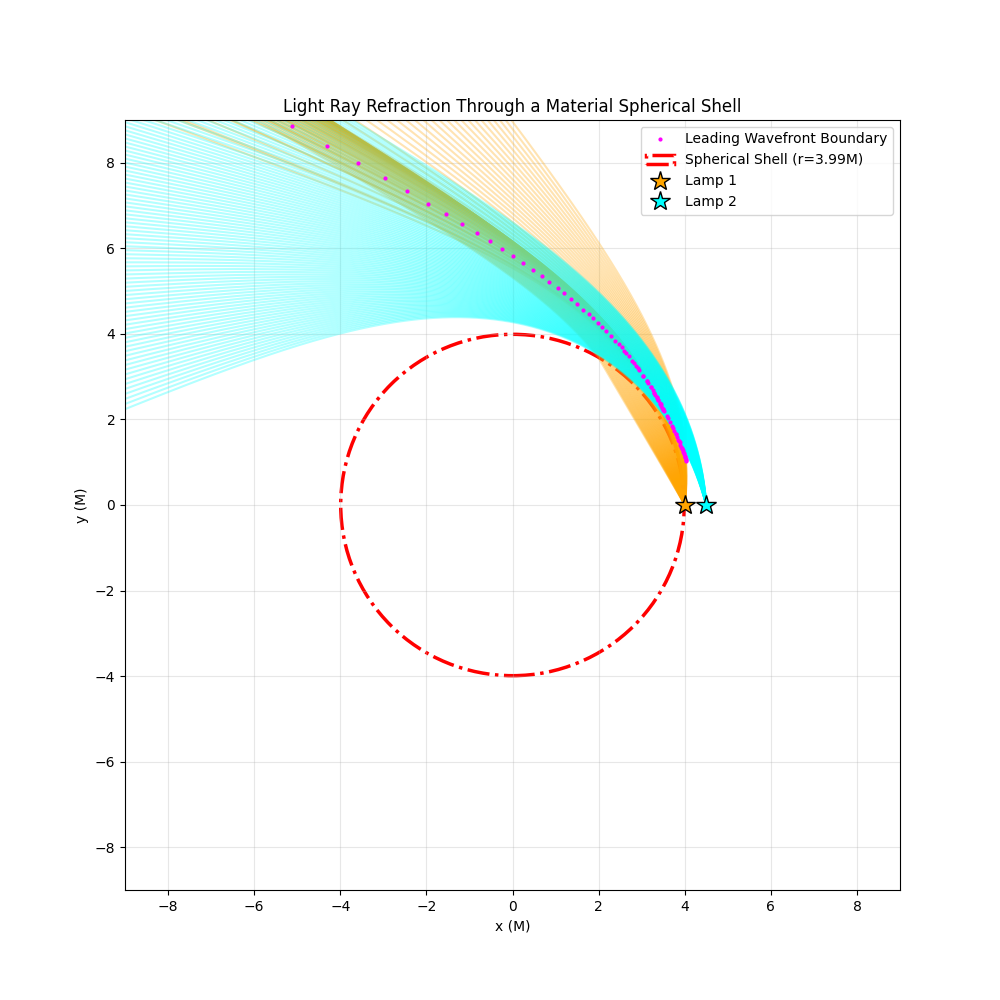

In [8]:
# ==========================================
# PLOTTING
# ==========================================
fig_size = (10, 10)
ray_alpha = 0.3
color_l1 = 'orange'
color_l2 = 'cyan'
intersect_color = 'magenta'

plt.figure(figsize=fig_size)

# Plot the full rays
for ray_id, ray in rays_lamp1.items():
    plt.plot(ray['x'], ray['y'], color=color_l1, alpha=ray_alpha)

for ray_id, ray in rays_lamp2.items():
    plt.plot(ray['x'], ray['y'], color=color_l2, alpha=ray_alpha)

# Plot Intersections
if len(intersections) > 0:
    intersections = intersections[intersections[:, 0].argsort()]
    plt.plot(intersections[:, 0], intersections[:, 1], 'o', color=intersect_color,
             linewidth=1.5, markersize=2, label='Leading Wavefront Boundary')

# Draw the Shell
shell = plt.Circle((0, 0), R, color='red', fill=False, linewidth=2.5, linestyle='-.', label=f'Spherical Shell (r={R}M)')
plt.gca().add_patch(shell)

# Draw Lamps
x1, y1 = lamp1.r0 * np.cos(lamp1.phi0), lamp1.r0 * np.sin(lamp1.phi0)
x2, y2 = lamp2.r0 * np.cos(lamp2.phi0), lamp2.r0 * np.sin(lamp2.phi0)
plt.plot(x1, y1, '*', color=color_l1, markeredgecolor='black', markersize=15, label=lamp1.label, zorder=5)
plt.plot(x2, y2, '*', color=color_l2, markeredgecolor='black', markersize=15, label=lamp2.label, zorder=5)

# Formatting
plt.xlabel('x (M)')
plt.ylabel('y (M)')
plt.title('Light Ray Refraction Through a Material Spherical Shell')
plt.xlim(-9, 9)
plt.ylim(-9, 9)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

Tracing 1000 rays for Lamp 1...
Tracing 1000 rays for Lamp 2...
Finding spacetime intersections...
Plotting results...


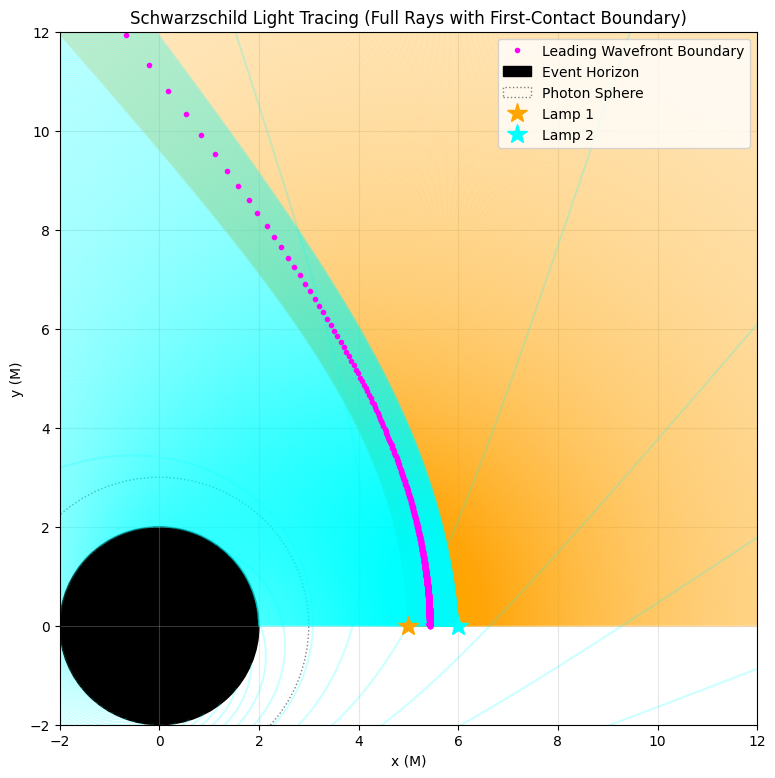

In [135]:
# Run simulation and plot
M = 1.0
spacetime = SchwarzschildSpacetime(M)

# Position your lamps
lamp1 = LightSource(r0=5.0 * M, phi0=0.0, label="Lamp 1")
lamp2 = LightSource(r0=6.0 * M, phi0=0.0, label="Lamp 2")

# ---------------------------------------------------------
# DEFINE EMISSION ANGLES
# ---------------------------------------------------------
# Lamp 1: A narrow 30-degree cone pointing perfectly inward
angles_lamp1 = np.linspace(np.radians(0), np.radians(91), 1000)

# Lamp 2: A wider 90-degree cone pointing perfectly inward
angles_lamp2 = np.linspace(np.radians(95), np.radians(180), 1000)
# ---------------------------------------------------------

data_lamp1 = []
data_lamp2 = []
rays_lamp1 = {}
rays_lamp2 = {}

plt.figure(figsize=(9, 9))

print(f"Tracing {len(angles_lamp1)} rays for Lamp 1...")
for i, angle in enumerate(angles_lamp1):
    sol = spacetime.trace_ray(lamp1, angle)
    if sol is not None:
        t, r, phi = sol.y[0], sol.y[1], sol.y[2]
        x, y = r * np.cos(phi), r * np.sin(phi)
        ray_ids = np.full_like(t, i)

        data_lamp1.extend(np.column_stack((t, x, y, ray_ids)))
        rays_lamp1[i] = {'t': t, 'x': x, 'y': y}

print(f"Tracing {len(angles_lamp2)} rays for Lamp 2...")
for i, angle in enumerate(angles_lamp2):
    sol = spacetime.trace_ray(lamp2, angle)
    if sol is not None:
        t, r, phi = sol.y[0], sol.y[1], sol.y[2]
        x, y = r * np.cos(phi), r * np.sin(phi)
        ray_ids = np.full_like(t, i)

        data_lamp2.extend(np.column_stack((t, x, y, ray_ids)))
        rays_lamp2[i] = {'t': t, 'x': x, 'y': y}

data_lamp1 = np.array(data_lamp1)
data_lamp2 = np.array(data_lamp2)

print("Finding spacetime intersections...")
intersections, death_times1, death_times2 = find_intersections(data_lamp1, data_lamp2, eps_t=0.05, eps_s=0.1)

print("Plotting results...")

# --- NEW PLOTTING LOGIC (No Truncation) ---

# Plot the full rays for Lamp 1
for ray_id, ray in rays_lamp1.items():
    plt.plot(ray['x'], ray['y'], color='orange', alpha=0.2)

# Plot the full rays for Lamp 2
for ray_id, ray in rays_lamp2.items():
    plt.plot(ray['x'], ray['y'], color='cyan', alpha=0.2)

# ------------------------------------------

# Plot Intersections
if len(intersections) > 0:
    intersections = intersections[intersections[:, 0].argsort()]
    plt.plot(intersections[:, 0], intersections[:, 1], 'o', color='magenta',
             linewidth=2.5, markersize=3, label='Leading Wavefront Boundary')
else:
    print("No intersections found.")

# Draw Environment
horizon = plt.Circle((0,0), 2*M, color='black', label='Event Horizon')
photon_sphere = plt.Circle((0,0), 3*M, color='gray', fill=False, linestyle=':', label='Photon Sphere')
plt.gca().add_patch(horizon)
plt.gca().add_patch(photon_sphere)

# Plot Lamps dynamically based on their object attributes
x1, y1 = lamp1.r0 * np.cos(lamp1.phi0), lamp1.r0 * np.sin(lamp1.phi0)
x2, y2 = lamp2.r0 * np.cos(lamp2.phi0), lamp2.r0 * np.sin(lamp2.phi0)
plt.plot(x1, y1, '*', color='orange', markersize=15, label=lamp1.label)
plt.plot(x2, y2, '*', color='cyan', markersize=15, label=lamp2.label)

plt.xlabel('x (M)')
plt.ylabel('y (M)')
plt.title('Schwarzschild Light Tracing (Full Rays with First-Contact Boundary)')
plt.xlim(-2, 12)
plt.ylim(-2, 12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()